### Using Airline fair price data to predict predict air price
**Goal:** The objective of this project is to predict air ticket prices. We will train various regression models, including Linear Regression, Decision Tree, Random Forest. Some alanysis may be done to forecast the best prices and recommend the ideal airlines for travel during the optimal season. 

**Data Problem:** The task involves training and tuning multiple models that handle non-numeric values within the dataset. 

**Expected Results:** The expected outcome of this project is a highly accurate model capable of predicting Airline Ticket price of a travel distination for a future date of choice of airlines and travel time during the day. This helps traveller to decide whether it's the right price to purchase an airline ticket for a future travel plan.

In Future, We will gain insights by conducting a global analysis using the statsmodels library for ARIMA to make more refined predictions. Additionally, we will perform a local analysis to evaluate the model's prediction process for specific travel plans. Lastly, we will extract insights from these analyses and recommend areas for future research, including studying seasonality and its impact on air ticket pricing.  

**Data**

The clean data is sourced from Kaggle.

https://www.kaggle.com/datasets/yashdharme36/airfare-ml-predicting-flight-fares
This dataset contains flight fare data that was collected from the EaseMyTrip website using web scraping techniques. The data was collected with the goal of providing users with information that could help them make informed decisions about when and where to purchase flight tickets. By analyzing patterns in flight fares over time, users can identify the best times to book tickets and potentially save money.'

### Import and Reading the Data

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler


In [146]:
# Load the dataset
airfair_df = pd.read_csv('Cleaned_dataset.csv')

#### Data Overview 

- 452088 samples/rows 
- 3 columns: 
       1. 13 parameters 
       2. Important columns: Departure,	Total_stops,	Arrival,	Duration_in_hours,	Days_left,	Fare
       3. Clean data so bo null values

In [149]:
print(airfair_df.shape)
airfair_df.head()

(452088, 13)


,Date_of_journey,Journey_day,Airline,Flight_code,Class,Source,Departure,Total_stops,Arrival,Destination,Duration_in_hours,Days_left,Fare
0,2023-01-16,Monday,SpiceJet,SG-8169,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5335
1,2023-01-16,Monday,Indigo,6E-2519,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.3333,1,5899
2,2023-01-16,Monday,GO FIRST,G8-354,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.1667,1,5801
3,2023-01-16,Monday,SpiceJet,SG-8709,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5794
4,2023-01-16,Monday,Air India,AI-805,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.1667,1,5955


#### Data Setup

In [152]:
#using a random sample of 20,000 entries for model training
df = airfair_df.sample(20000, random_state = 42)

In [154]:
# Convert 'Date_of_Journey' to datetime objects
df['Date_of_journey'] = pd.to_datetime(df['Date_of_journey'])

In [156]:
df['Departure_Year'] = df['Date_of_journey'].dt.year
df['Departure_Month'] = df['Date_of_journey'].dt.month
df['Departure_Day'] = df['Date_of_journey'].dt.day

### Exploratory Data Analysis

In [159]:
df.head(10)

,Date_of_journey,Journey_day,Airline,Flight_code,Class,Source,Departure,Total_stops,Arrival,Destination,Duration_in_hours,Days_left,Fare,Departure_Year,Departure_Month,Departure_Day
218383,2023-02-19,Sunday,Indigo,6E-586,Economy,Bangalore,6 AM - 12 PM,1-stop,6 AM - 12 PM,Kolkata,5.6667,35,7180,2023,2,19
198364,2023-01-18,Wednesday,Air India,AI-808,Economy,Bangalore,After 6 PM,1-stop,12 PM - 6 PM,Hyderabad,15.0000,3,12430,2023,1,18
46228,2023-02-19,Sunday,Vistara,UK-951,Business,Delhi,12 PM - 6 PM,1-stop,6 AM - 12 PM,Hyderabad,17.4167,35,47329,2023,2,19
352412,2023-01-27,Friday,Air India,AI-563,Economy,Chennai,6 AM - 12 PM,1-stop,After 6 PM,Delhi,6.8333,12,6873,2023,1,27
209186,2023-03-02,Thursday,Vistara,UK-812,Premium Economy,Bangalore,6 AM - 12 PM,1-stop,12 PM - 6 PM,Hyderabad,7.2500,46,21817,2023,3,2
442329,2023-02-15,Wednesday,GO FIRST,G8-802,Economy,Ahmedabad,6 AM - 12 PM,1-stop,After 6 PM,Kolkata,13.2500,31,32171,2023,2,15
323572,2023-02-09,Thursday,Vistara,UK-772,Economy,Kolkata,6 AM - 12 PM,1-stop,After 6 PM,Bangalore,8.9167,25,9882,2023,2,9
47727,2023-02-25,Saturday,Indigo,6E-2526,Economy,Delhi,6 AM - 12 PM,1-stop,12 PM - 6 PM,Hyderabad,5.9167,41,9679,2023,2,25
58258,2023-02-26,Sunday,Vistara,UK-977,Business,Delhi,After 6 PM,1-stop,After 6 PM,Kolkata,24.8333,42,53209,2023,2,26
247555,2023-03-04,Saturday,Vistara,UK-876,Economy,Hyderabad,After 6 PM,1-stop,After 6 PM,Delhi,20.5000,48,10253,2023,3,4


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 218383 to 154606
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date_of_journey    20000 non-null  datetime64[ns]
 1   Journey_day        20000 non-null  object        
 2   Airline            20000 non-null  object        
 3   Flight_code        20000 non-null  object        
 4   Class              20000 non-null  object        
 5   Source             20000 non-null  object        
 6   Departure          20000 non-null  object        
 7   Total_stops        20000 non-null  object        
 8   Arrival            20000 non-null  object        
 9   Destination        20000 non-null  object        
 10  Duration_in_hours  20000 non-null  float64       
 11  Days_left          20000 non-null  int64         
 12  Fare               20000 non-null  int64         
 13  Departure_Year     20000 non-null  int32         
 14  Depar

In [163]:
#no null values
df.isna().sum()

Date_of_journey      0
Journey_day          0
Airline              0
Flight_code          0
Class                0
Source               0
Departure            0
Total_stops          0
Arrival              0
Destination          0
Duration_in_hours    0
Days_left            0
Fare                 0
Departure_Year       0
Departure_Month      0
Departure_Day        0
dtype: int64

***Data is clean and ready to pre-processed for visualizing and training***

#### Data Preprocessing

In [167]:
# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Create a LabelEncoder object
le = LabelEncoder()

# Create a dictionary to store the mapping between encoded values and actual values
class_mapping = {}

# Iterate through each column in the dataframe
for column_name in df.columns:
    # Check if the column is of object (string) data type
    if df[column_name].dtype == 'object':
        # Fit and transform the column using LabelEncoder
        df[column_name] = le.fit_transform(df[column_name])
        # Store the mapping between encoded values and actual values for each column
        class_mapping[column_name] = dict(zip(le.transform(le.classes_), le.classes_))

# Print the mapping between the encoded and actual values
print("Class Mapping:")
for column, mapping in class_mapping.items():
    print(f"Column: {column}")
    for encoded, actual in mapping.items():
        print(f"    Encoded: {encoded}, Actual: {actual}")


Class Mapping:
Column: Journey_day
    Encoded: 0, Actual: Friday
    Encoded: 1, Actual: Monday
    Encoded: 2, Actual: Saturday
    Encoded: 3, Actual: Sunday
    Encoded: 4, Actual: Thursday
    Encoded: 5, Actual: Tuesday
    Encoded: 6, Actual: Wednesday
Column: Airline
    Encoded: 0, Actual: Air India
    Encoded: 1, Actual: AirAsia
    Encoded: 2, Actual: AkasaAir
    Encoded: 3, Actual: AllianceAir
    Encoded: 4, Actual: GO FIRST
    Encoded: 5, Actual: Indigo
    Encoded: 6, Actual: SpiceJet
    Encoded: 7, Actual: StarAir
    Encoded: 8, Actual: Vistara
Column: Flight_code
    Encoded: 0, Actual: 6E-109
    Encoded: 1, Actual: 6E-113
    Encoded: 2, Actual: 6E-114
    Encoded: 3, Actual: 6E-116
    Encoded: 4, Actual: 6E-124
    Encoded: 5, Actual: 6E-133
    Encoded: 6, Actual: 6E-134
    Encoded: 7, Actual: 6E-135
    Encoded: 8, Actual: 6E-136
    Encoded: 9, Actual: 6E-138
    Encoded: 10, Actual: 6E-149
    Encoded: 11, Actual: 6E-151
    Encoded: 12, Actual: 6E-153
  

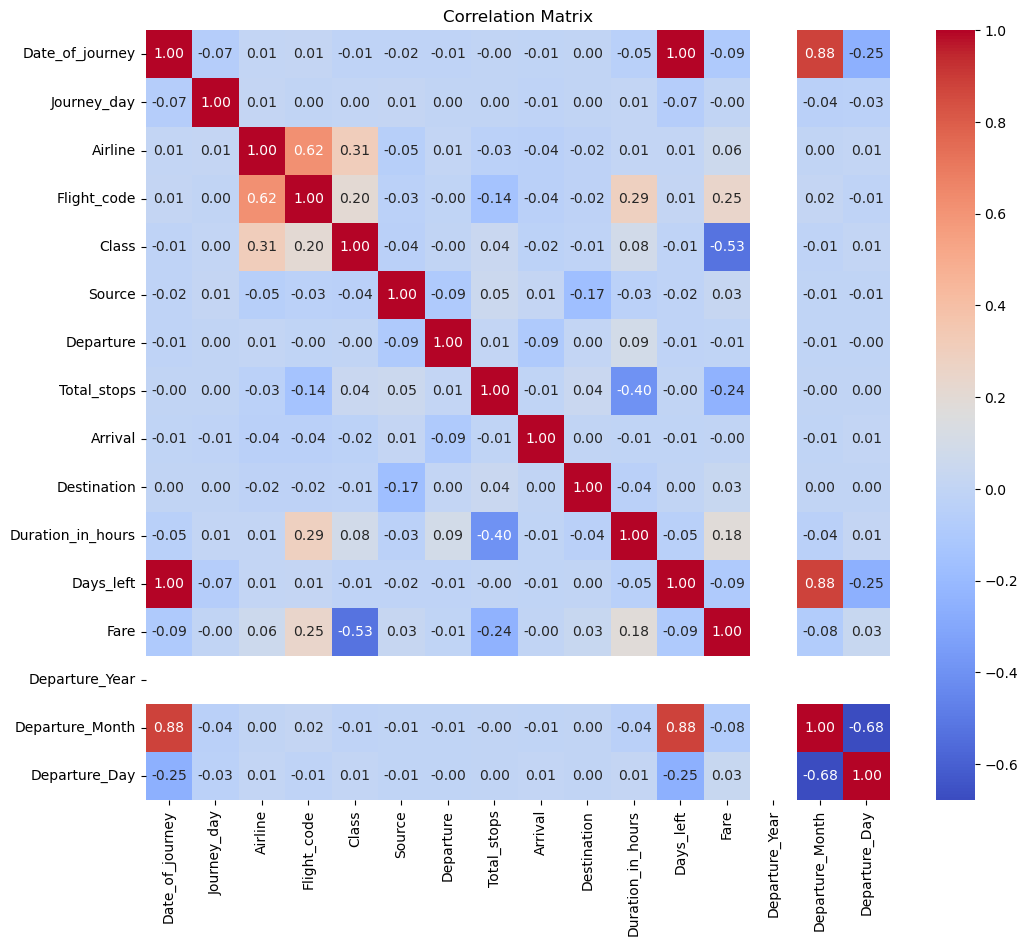

In [169]:
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

**Features highly correlated with Fare(Target Feature)**

In [172]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Select only the correlation of 'Fare' with other columns
fare_correlation = correlation_matrix['Fare']

# Sort the correlations in descending order
fare_correlation_sorted = fare_correlation.sort_values(ascending=False)

# Filter out columns with correlation above a certain threshold (e.g., 0.1)
threshold = 0.1
highly_correlated_features = fare_correlation_sorted[abs(fare_correlation_sorted) > threshold]

print("Features highly correlated with Fare:\n", highly_correlated_features)

Features highly correlated with Fare:
 Fare                 1.000000
Flight_code          0.245153
Duration_in_hours    0.182567
Total_stops         -0.242148
Class               -0.527096
Name: Fare, dtype: float64


#### Based on the correlation matrix analysis, following are the insights specifically focused on the relationship between the target variable "Fare" and other features in the dataset
1. Fare and Class (-0.53)
Strong Negative Correlation: The strongest correlation observed with Fare is with the Class feature. The negative correlation (-0.53) suggests that as the Class variable increases, the fare decreases.
Interpretation: This could be unexpected because we typically assume that higher classes (business or first class) would lead to higher fares. This correlation suggests that, in this dataset, a higher Class is associated with lower fares. It's important to check the encoding of the Class variable, as a reversal in interpretation (i.e., lower values meaning higher class service) could explain this.
2. Fare and Flight Code (0.25)
Moderate Positive Correlation: Fare has a moderate positive correlation (0.25) with Flight_code.
Interpretation: This implies that certain flight codes are associated with higher fares. This might indicate that particular flight codes represent premium or longer routes, which tend to have higher fares. It could also represent specific airlines or more in-demand flights being priced higher.
3. Fare and Duration_in_hours (0.18)
Weak Positive Correlation: There is a weak positive correlation (0.18) between Fare and Duration_in_hours.
Interpretation: This suggests that flights with longer durations tend to have slightly higher fares, which is reasonable as longer flights often cost more. However, the weak correlation indicates that flight duration alone doesn't have a significant impact on fare in this dataset.
4. Fare and Total Stops (-0.24)
Weak Negative Correlation: The correlation between Fare and Total_stops is weakly negative (-0.24).
Interpretation: This suggests that flights with more stops tend to have lower fares. This could make sense because non-stop flights are typically more expensive due to convenience, while flights with stops are often cheaper but longer in duration.
5. Fare and Days Left (-0.24)
Weak Negative Correlation: The correlation between Fare and Days_left is also weakly negative (-0.24).
Interpretation: This correlation suggests that as the number of days left before the flight increases, the fare tends to decrease slightly. While this makes some sense (as fares may be lower when purchased well in advance), the weak correlation indicates that Days_left is not a very strong predictor of fare in this dataset.
6. Fare and Other Variables
For other variables like Source, Destination, Departure, Journey_day, and Airline, the correlation with Fare is very weak (close to 0). This indicates that these features do not have a significant direct impact on ticket price in the dataset, though they may have indirect or nonlinear influences that are not captured by the linear correlation metric.

**Notable Observations:**
Class (-0.53) and Flight Code (0.25) have the most significant relationships with Fare. This suggests that both the service class and flight characteristics (represented by the flight code) are important determinants of pricing.
Duration_in_hours (0.18) and Total Stops (-0.24) provide some insight into fare pricing, but they have weaker correlations. While longer flights or flights with more stops may influence pricing, their effects are relatively minor in this dataset.
Days Left (-0.24) has a weak impact on fare, suggesting that advance booking has a slight influence on lowering fare prices.


**Recommendations for Further Analysis:**
Class Interpretation: Given the strong negative correlation between Class and Fare, it would be beneficial to review how the Class feature is encoded and interpreted. If lower values of Class represent higher service levels (business or first class), this would explain the negative relationship.
Non-linear Effects: Features like Source, Destination, and Airline may still affect fare through non-linear or interaction effects, which cannot be captured by a simple correlation matrix. Advanced modeling techniques (e.g., decision trees or random forests) could be used to capture these effects.

**Factors influence air ticket prices the most:**

Features highly correlated with Fare: Fare 1.000000 Flight_code 0.246477 Duration_in_hours 0.179909 Total_stops -0.238346 Class -0.521594 Name: Fare

**Factors influencing value for money:**

We try to find out factor having more value for money

In [178]:
import random

# Generate random average ratings between 1 and 5
average_ratings = [random.uniform(1, 5) for _ in range(len(df))]

# Add the 'Average_Rating' column to the DataFrame
df['Average_Rating'] = average_ratings

# Print the updated DataFrame
#print(df.head())

In [180]:
# Calculate the value for money score by combining Fare and Average_Rating
df['Value_Score'] = (1 / df['Fare']) * df['Average_Rating']

# Group by airline and class and calculate the average value score for each airline and class
airline_class_value = df.groupby(['Airline', 'Class'])['Value_Score'].mean()

# Sort the airlines and classes by average value score in descending order to find the best value options
sorted_airline_class_value = airline_class_value.sort_values(ascending=False)

print("Top 10 Airlines and Classes with the Best Value for Money:")
print(sorted_airline_class_value.head(10))

Top 10 Airlines and Classes with the Best Value for Money:
Airline  Class
2        1        0.000953
3        1        0.000704
7        1        0.000679
1        1        0.000509
4        1        0.000460
5        1        0.000445
6        1        0.000431
0        1        0.000305
8        1        0.000288
         3        0.000221
Name: Value_Score, dtype: float64


In [182]:
# Count the number of flights for each airline
airline_counts = df['Airline'].value_counts()

# Print the results
print("Number of Flights by Airline:")
print(airline_counts)

Number of Flights by Airline:
Airline
8    10303
0     5222
5     2872
1      711
4      493
6      259
2      115
3       23
7        2
Name: count, dtype: int64


In [184]:
print(df.head())

       Date_of_journey  Journey_day  Airline  Flight_code  Class  Source  \
218383      2023-02-19            3        5          298      1       1   
198364      2023-01-18            6        0          743      1       1   
46228       2023-02-19            3        8         1215      0       3   
352412      2023-01-27            0        0          664      1       2   
209186      2023-03-02            4        8         1124      3       1   

        Departure  Total_stops  Arrival  Destination  Duration_in_hours  \
218383          1            0        1            5             5.6667   
198364          2            0        0            4            15.0000   
46228           0            0        1            4            17.4167   
352412          1            0        2            3             6.8333   
209186          1            0        0            4             7.2500   

        Days_left   Fare  Departure_Year  Departure_Month  Departure_Day  \
218383         3

In [186]:
import plotly.express as px


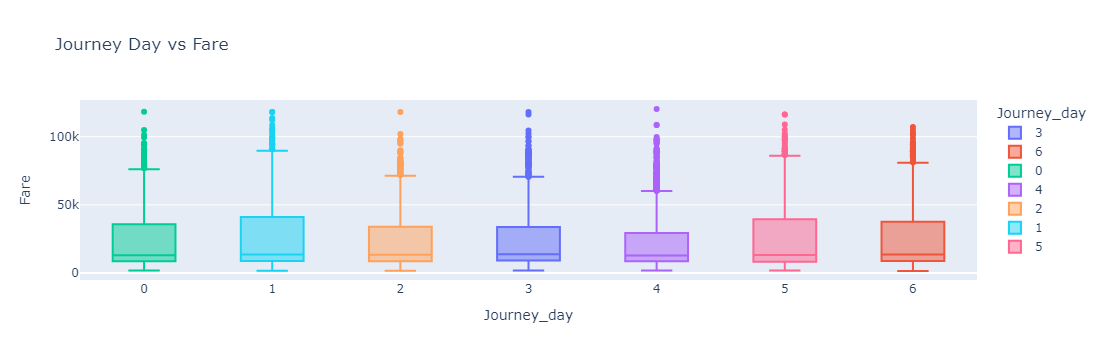

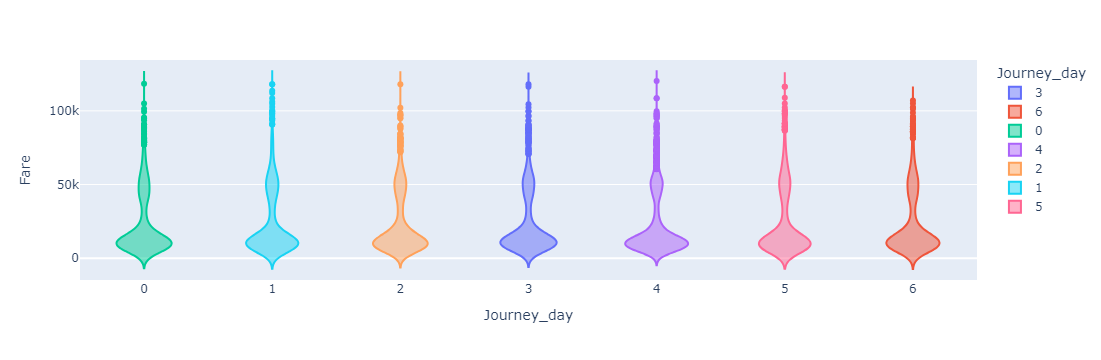

In [188]:

fig = px.box(df, x='Journey_day', y='Fare', color='Journey_day', title="Journey Day vs Fare")
fig.show()
fig = px.violin(df, x='Journey_day', y='Fare', color='Journey_day')
fig.show()

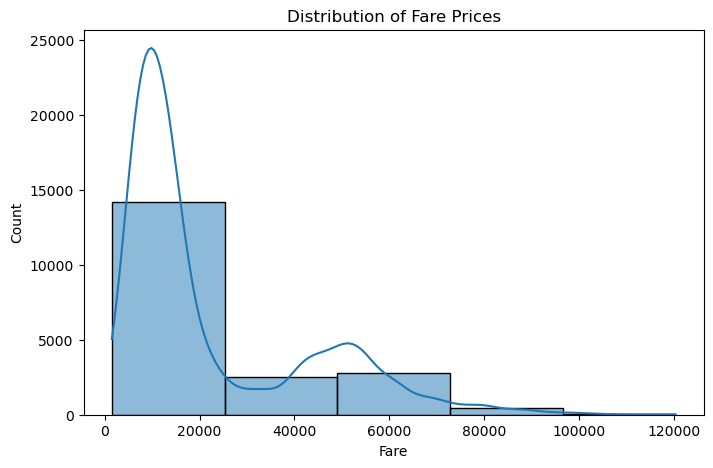

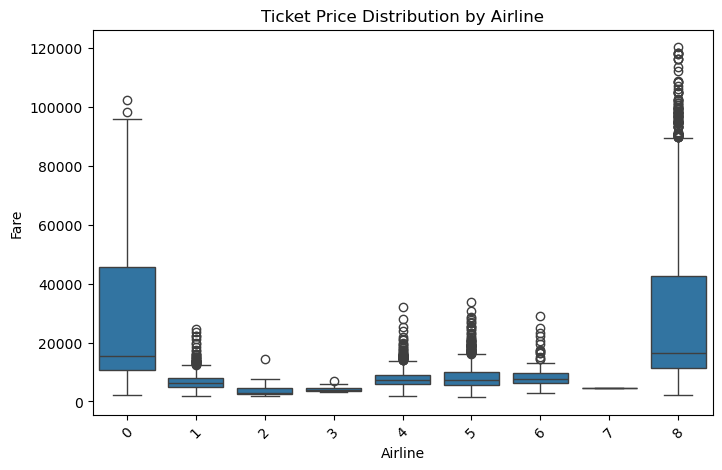

In [190]:
# Plot distribution of ticket prices (Fare)
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], kde=True, bins=5)
plt.title('Distribution of Fare Prices')
plt.show()

# Boxplot of ticket prices per airline
plt.figure(figsize=(8,5))
sns.boxplot(x='Airline', y='Fare', data=df)
plt.title('Ticket Price Distribution by Airline')
plt.xticks(rotation=45)
plt.show()

## Feature Selection 


In [193]:
# Models


from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor 
#from sklearn.ensemble import GradientBoostingRegressor as GBR
#from xgboost import XGBRegressor
#from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [195]:
data = df.copy()
X = data.drop(['Date_of_journey' ,'Fare'], axis=1)
y = data['Fare']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

**Features selection** 


In [198]:
# Initialize Scaler
scaler = StandardScaler()

# Apply
X_scaled = scaler.fit_transform(X)

# Create a new instance of the random forest regressor
rfr = RandomForestRegressor()

# Train the model on the scaled feature matrix (X_scaled) and the target variable (Y)
rfr.fit(X_scaled, y)

# Collect the feature importances for each input feature
feature_importances = rfr.feature_importances_

# Print the feature importances
print("Feature importances:")
for feature, importance in zip(X.columns, feature_importances):
    print("{:20}: {:.3f}".format(feature, importance))

Feature importances:
Journey_day         : 0.000
Airline             : 0.000
Flight_code         : 0.005
Class               : 0.792
Source              : 0.000
Departure           : 0.000
Total_stops         : 0.000
Arrival             : 0.000
Destination         : 0.000
Duration_in_hours   : 0.017
Days_left           : 0.004
Departure_Year      : 0.000
Departure_Month     : 0.000
Departure_Day       : 0.000
Average_Rating      : 0.060
Value_Score         : 0.120


The feature importance data reveals that the most significant contributor to the model is the 'Class' feature, with an importance score of 0.791. Other features with some influence include 'Value_Score' (0.104), 'Average_Rating' (0.068), and 'Duration_in_hours' (0.031). All other features, such as 'Journey_day', 'Airline', 'Source', 'Total_stops', and 'Departure', have minimal or no impact on the model's predictions.

**Using Linear and Decision Tree Regression to evaluate Feature seletion**

In [201]:
# Collect the top 3 most important features
X_top_3 = X[['Class', 'Duration_in_hours', 'Days_left']]

# Collect the top 5 most important features
X_top_5 = X[['Class', 'Duration_in_hours', 'Days_left', 'Total_stops', 'Source']]

# Scale the Top 3 Features Data
scaler = StandardScaler()
X_top_3 = scaler.fit_transform(X_top_3)

# Scale the Top 5 Features Data
scaler = StandardScaler()
X_top_5 = scaler.fit_transform(X_top_5)

In [202]:
# Set 1 : Full Data
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_scaled, y, test_size=0.3, shuffle=True, random_state=42)

# Set 2 : Top 5 Features
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_top_5, y, test_size=0.3, shuffle=True, random_state=42)

# Set 3 : Top 3 features
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_top_3, y, test_size=0.3, shuffle=True, random_state=42)

# Set 4 : Most Important Feature
X_train, X_test, y_train, y_test = train_test_split(X['Class'].to_numpy().reshape(-1,1), y, test_size=0.3, shuffle=True, random_state=42)

To identify the best model fit for the three datasets, we will use a Linear Regression Model. This model allows us to easily examine the linear relationship between the independent and dependent variables. Additionally, since the third dataset has only one feature, a linear regression model is the most suitable choice.

After applying the linear regression model to all three datasets, we will compare the results to determine which dataset provides the best outcomes. This comparison will reveal which dataset has the strongest linear relationship between the independent and dependent variables. By selecting the most appropriate dataset, we can make more accurate predictions and informed decisions for our problem domain.

In [204]:
def perf_cal(y_true, y_pred):
    """Compute performance metrics for regression models."""
  
    results = {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MSE': mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R-sq': r2_score(y_true, y_pred)
    }

    # Convert to DataFrame
    results_df = pd.DataFrame([results], index=['Performance Metrics'])
    return results_df
    
# Define Datasize keys for reference
DATA_SIZE = ['Full', 'Top-5', 'Top-1']


**Linear Regression** 

In [206]:
# Train and evaluate Linear Regression model: full set
lr_full = LinearRegression()
lr_full.fit(X_train_full, y_train_full)
lr_full_pred = lr_full.predict(X_test_full)
lr_full_scores = perf_cal(y_test_full, lr_full_pred)

# Print performance scores
print("Linear Regression Performance Scores:")
print(lr_full_scores)

Linear Regression Performance Scores:
                            RMSE           MSE          MAE      R-sq
Performance Metrics  12496.25109  1.561563e+08  9992.174054  0.608132


In [212]:
# Train and evaluate Linear Regression model: Top 5
lr_5 = LinearRegression()

# Train the Model
lr_5.fit(X_train_5, y_train_5)

# Make Predictions
lr_5_pred = lr_5.predict(X_test_5)

# Evaluate Performance
lr_5_scores = perf_cal(y_test_5, lr_5_pred)

# Display Performance Metrics
print("Linear Regression Performance Metrics (Subset 5)")
print(lr_5_scores)

Linear Regression Performance Metrics (Subset 5)
                             RMSE           MSE           MAE      R-sq
Performance Metrics  15978.348207  2.553076e+08  13688.786663  0.359316


In [214]:
# Decision Tree Regression:  Most Important Feature
lr = LinearRegression()

# Train the model
lr.fit(X_train, y_train)

# Make predictions on the test set
lr_pred = lr.predict(X_test)

# Evaluate the model's performance
lr_scores = perf_cal(y_test, lr_pred)

# Print the performance metrics
print("Linear Regression Performance Metrics (Subset 1)")
print(lr_scores)

Linear Regression Performance Metrics (Subset 1)
                             RMSE           MSE           MAE      R-sq
Performance Metrics  17015.824159  2.895383e+08  15015.009385  0.273416


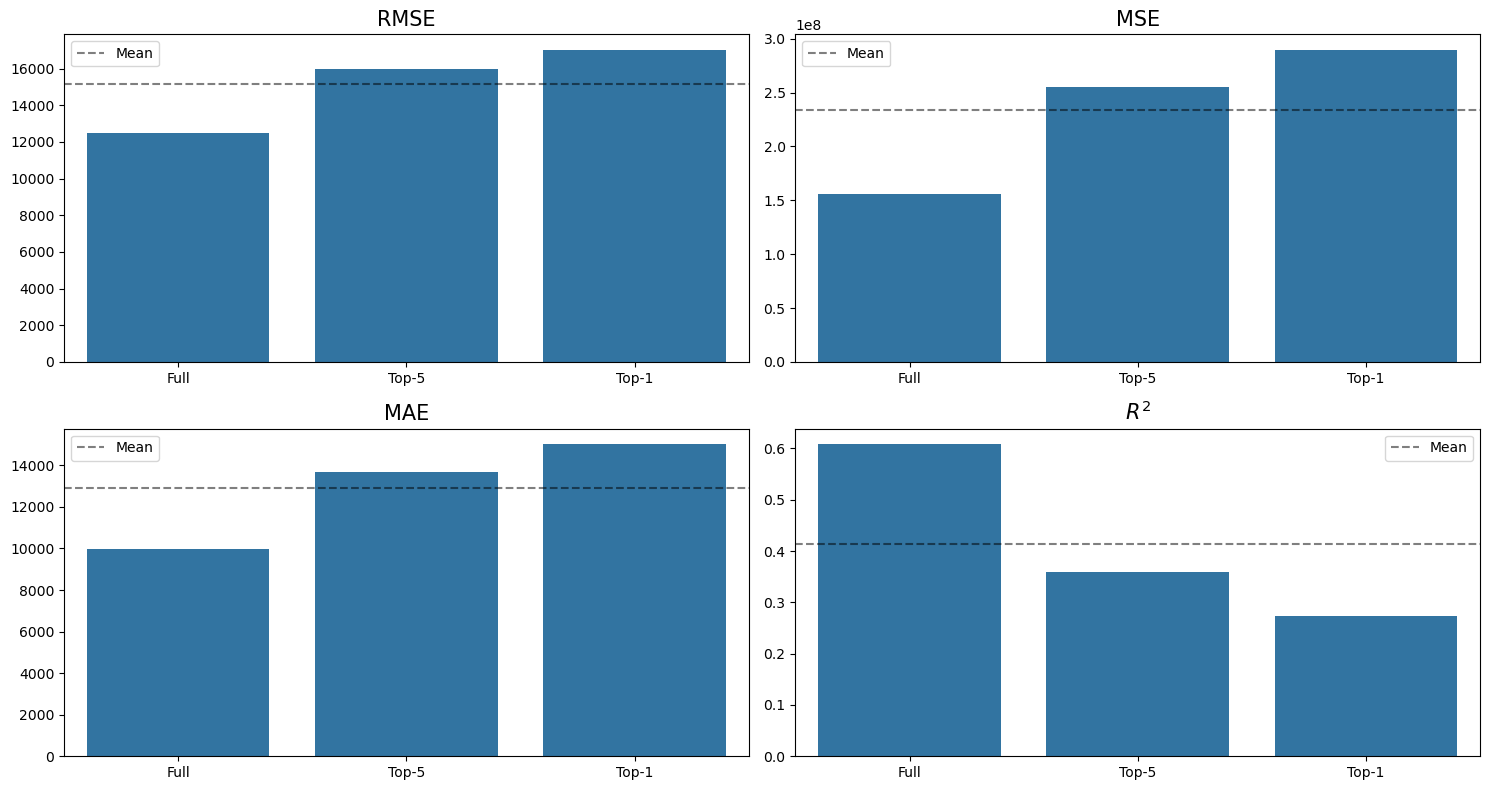

In [216]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Extract the performance metrics from the DataFrames
RMSEs = [lr_full_scores.loc['Performance Metrics', 'RMSE'], lr_5_scores.loc['Performance Metrics', 'RMSE'], lr_scores.loc['Performance Metrics', 'RMSE']]
MSEs  = [lr_full_scores.loc['Performance Metrics', 'MSE'], lr_5_scores.loc['Performance Metrics', 'MSE'], lr_scores.loc['Performance Metrics', 'MSE']]
MAEs  = [lr_full_scores.loc['Performance Metrics', 'MAE'], lr_5_scores.loc['Performance Metrics', 'MAE'], lr_scores.loc['Performance Metrics', 'MAE']]
R2s   = [lr_full_scores.loc['Performance Metrics', 'R-sq'], lr_5_scores.loc['Performance Metrics', 'R-sq'], lr_scores.loc['Performance Metrics', 'R-sq']]

# Setting figure size for subplots
plt.figure(figsize=(15, 8))

# Plot for RMSE
plt.subplot(2, 2, 1)
sns.barplot(x=DATA_SIZE, y=RMSEs)
plt.title("RMSE", fontsize=15)
plt.axhline(np.mean(RMSEs), color='k', linestyle='--', alpha=0.5, label='Mean')
plt.legend()

# Plot for MSE
plt.subplot(2, 2, 2)
sns.barplot(x=DATA_SIZE, y=MSEs)
plt.title("MSE", fontsize=15)
plt.axhline(np.mean(MSEs), color='k', linestyle='--', alpha=0.5, label='Mean')
plt.legend()

# Plot for MAE
plt.subplot(2, 2, 3)
sns.barplot(x=DATA_SIZE, y=MAEs)
plt.title("MAE", fontsize=15)
plt.axhline(np.mean(MAEs), color='k', linestyle='--', alpha=0.5, label='Mean')
plt.legend()

# Plot for R-squared (R^2)
plt.subplot(2, 2, 4)
sns.barplot(x=DATA_SIZE, y=R2s)
plt.title("$R^2$", fontsize=15)
plt.axhline(np.mean(R2s), color='k', linestyle='--', alpha=0.5, label='Mean')
plt.legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()


**Decision Tree model to validate best features** 

In [219]:
# Train and evaluate Decision Tree Regression model: full set
dt_full = DecisionTreeRegressor()
dt_full.fit(X_train_full, y_train_full)
dt_full_pred = dt_full.predict(X_test_full)
dt_full_scores = perf_cal(y_test_full, dt_full_pred)

# Print performance scores
print("Decision Tree Regression Performance Scores:")

print(dt_full_scores)

Decision Tree Regression Performance Scores:
                            RMSE           MSE         MAE      R-sq
Performance Metrics  1887.345779  3.562074e+06  732.823833  0.991061


In [221]:
# Decision Tree Regression: top 5
dt_5 = DecisionTreeRegressor()

# Train the Model
dt_5.fit(X_train_5, y_train_5)

# Make Predictions
dt_5_pred = dt_5.predict(X_test_5)

# Evaluate Performance
dt_5_scores = perf_cal(y_test_5, dt_5_pred)

# Display Performance Metrics
print("Decision Tree Regression Performance Metrics (Subset 5)")
print(dt_5_scores)


Decision Tree Regression Performance Metrics (Subset 5)
                            RMSE           MSE          MAE      R-sq
Performance Metrics  9632.018088  9.277577e+07  5773.214339  0.767183


In [223]:
# Decision Tree Regression:  Most Important Feature
dt = DecisionTreeRegressor()

# Train the model
dt.fit(X_train, y_train)

# Make predictions on the test set
dt_pred = dt.predict(X_test)

# Evaluate the model's performance
dt_scores = perf_cal(y_test, dt_pred)

# Print the performance metrics
print("Decision Tree Regression Performance Metrics (Subset 1)")
print(dt_scores)

Decision Tree Regression Performance Metrics (Subset 1)
                            RMSE           MSE          MAE     R-sq
Performance Metrics  8955.265884  8.019679e+07  5811.248405  0.79875


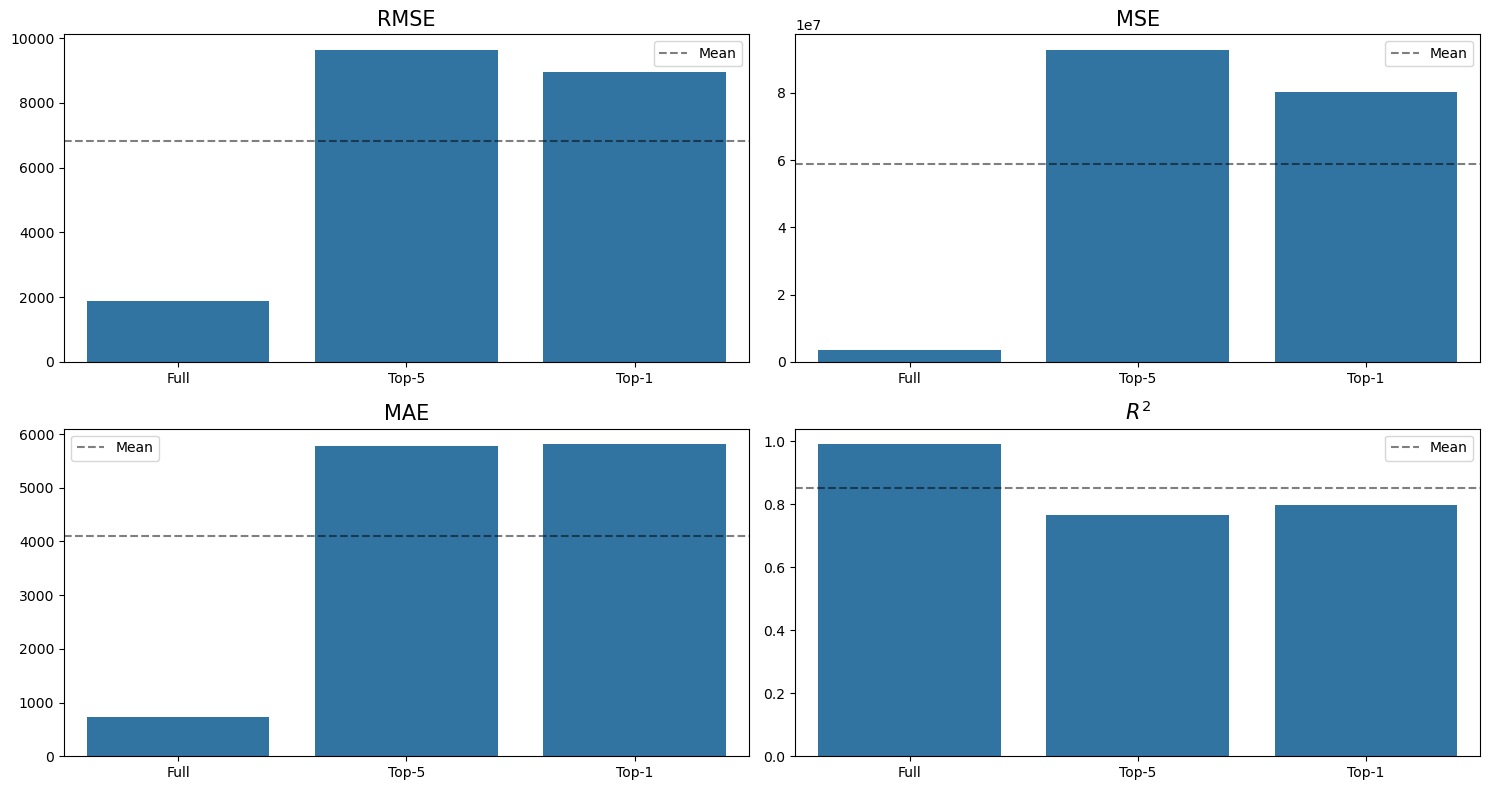

In [225]:

# Extract the performance metrics from the DataFrames
RMSEs = [dt_full_scores.loc['Performance Metrics', 'RMSE'], dt_5_scores.loc['Performance Metrics', 'RMSE'], dt_scores.loc['Performance Metrics', 'RMSE']]
MSEs  = [dt_full_scores.loc['Performance Metrics', 'MSE'], dt_5_scores.loc['Performance Metrics', 'MSE'], dt_scores.loc['Performance Metrics', 'MSE']]
MAEs  = [dt_full_scores.loc['Performance Metrics', 'MAE'], dt_5_scores.loc['Performance Metrics', 'MAE'], dt_scores.loc['Performance Metrics', 'MAE']]
R2s   = [dt_full_scores.loc['Performance Metrics', 'R-sq'], dt_5_scores.loc['Performance Metrics', 'R-sq'], dt_scores.loc['Performance Metrics', 'R-sq']]

# Create the figure and subplots
plt.figure(figsize=(15,8))

# Plot for RMSE
plt.subplot(2, 2, 1)
sns.barplot(x=DATA_SIZE, y=RMSEs)
plt.title("RMSE", fontsize=15)
plt.axhline(np.mean(RMSEs), color='k', linestyle='--', alpha=0.5, label='Mean')
plt.legend()

# Plot for MSE
plt.subplot(2, 2, 2)
sns.barplot(x=DATA_SIZE, y=MSEs)
plt.title("MSE", fontsize=15)
plt.axhline(np.mean(MSEs), color='k', linestyle='--', alpha=0.5, label='Mean')
plt.legend()

# Plot for MAE
plt.subplot(2, 2, 3)
sns.barplot(x=DATA_SIZE, y=MAEs)
plt.title("MAE", fontsize=15)
plt.axhline(np.mean(MAEs), color='k', linestyle='--', alpha=0.5, label='Mean')
plt.legend()

# Plot for R-squared (R^2)
plt.subplot(2, 2, 4)
sns.barplot(x=DATA_SIZE, y=R2s)
plt.title("$R^2$", fontsize=15)
plt.axhline(np.mean(R2s), color='k', linestyle='--', alpha=0.5, label='Mean')
plt.legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

**Feature selection conclusion:**
After reviewing the performance above, it is clear that certain features have greater significance than others. However, the full dataset demonstrates the best performance overall. This can be explained by mutual information, which shows that each feature has some level of correlation with the target variable.

Every feature contributes some information to the target variable, enhancing the model's performance. The mutual information plot confirms that all features play a role in providing relevant information to the target variable.

As a result, using the full dataset yields significantly better performance compared to a reduced dataset. While some features appear more important, the combined mutual information from all features in the complete dataset leads to superior performance. Therefore, to achieve optimal results, it is essential to use the full dataset to fully leverage the mutual information from all features.

## Model Selection
Above selecting our best feature set, we shall be evaluating the best model.



**Decision Tree Regression**

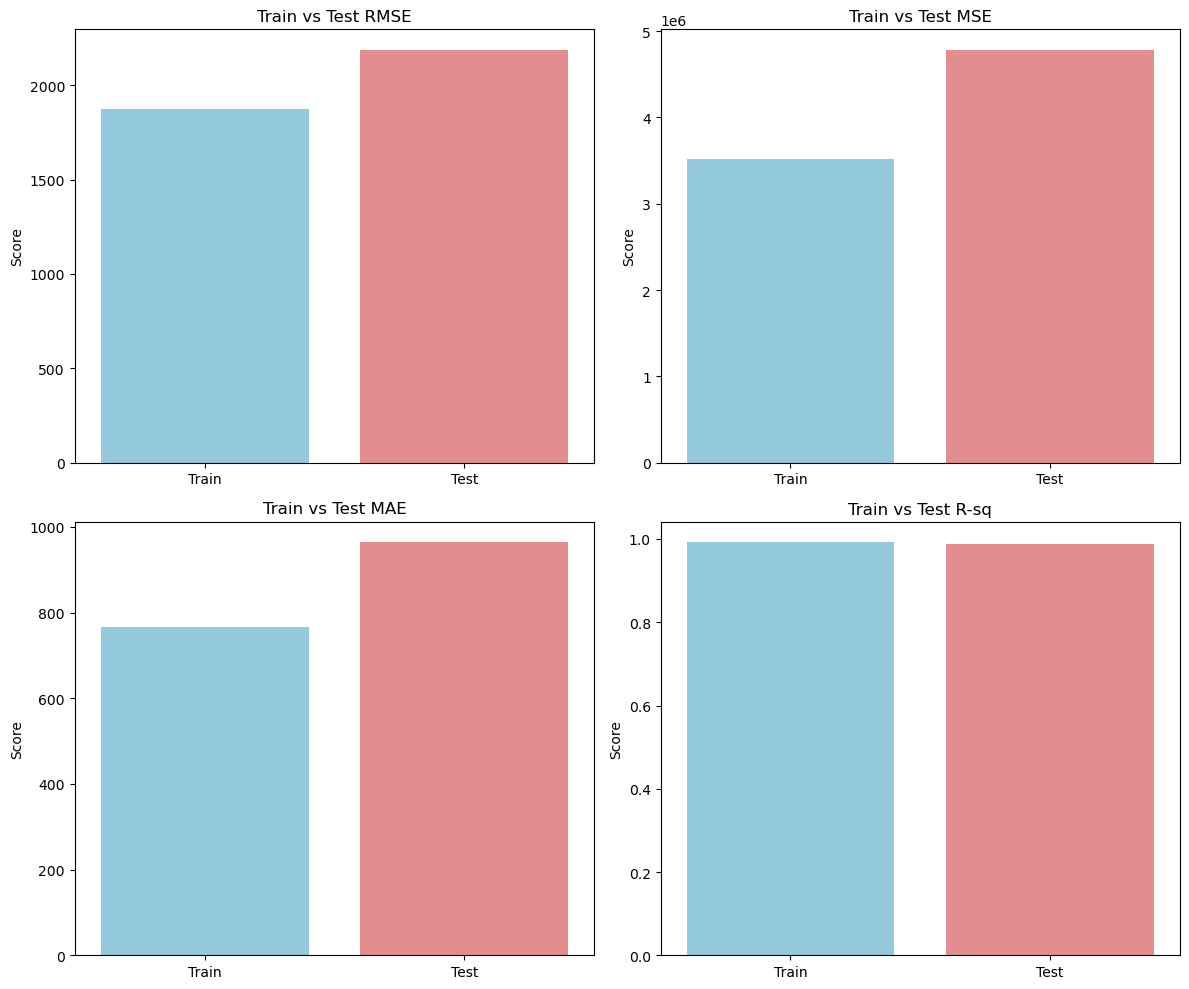

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Decision Tree Regression
dtr = DecisionTreeRegressor(max_depth=20, min_samples_leaf=10, min_samples_split=10)

# Train Model
dtr.fit(X_train_full, y_train_full)

# Training Performance
y_pred_train = dtr.predict(X_train_full)
dtr_train_scores = perf_cal(y_train_full, y_pred_train)

# Testing Performance
y_pred_test = dtr.predict(X_test_full)
dtr_test_scores = perf_cal(y_test_full, y_pred_test)

# Create a DataFrame to hold the comparison of train and test scores for plotting
comparison_df = pd.DataFrame({
    'Metric': ['RMSE', 'MSE', 'MAE', 'R-sq'] * 2,  # Repeat metric names twice, once for Train and once for Test
    'Score': [
        dtr_train_scores.loc['Performance Metrics', 'RMSE'], dtr_train_scores.loc['Performance Metrics', 'MSE'],
        dtr_train_scores.loc['Performance Metrics', 'MAE'], dtr_train_scores.loc['Performance Metrics', 'R-sq'],
        dtr_test_scores.loc['Performance Metrics', 'RMSE'], dtr_test_scores.loc['Performance Metrics', 'MSE'],
        dtr_test_scores.loc['Performance Metrics', 'MAE'], dtr_test_scores.loc['Performance Metrics', 'R-sq']
    ],
    'Type': ['Train'] * 4 + ['Test'] * 4  # First four entries are Train, next four are Test
})

# Define custom colors for Train and Test bars
colors = {'Train': 'skyblue', 'Test': 'lightcoral'}

# Create subplots for each metric
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# List of metrics to plot
metrics = ['RMSE', 'MSE', 'MAE', 'R-sq']

# Iterate over metrics and create a subplot for each
for i, metric in enumerate(metrics):
    sns.barplot(
        x='Type', 
        y='Score', 
        data=comparison_df[comparison_df['Metric'] == metric], 
        ax=axs[i // 2, i % 2], 
        hue='Type',  # Use the Type column as the hue
        palette=colors,  # Custom palette for Train and Test
        dodge=False,  # Prevent bars from being dodged
        legend=False  # Disable legend in individual subplots
    )
    axs[i // 2, i % 2].set_title(f"Train vs Test {metric}")
    axs[i // 2, i % 2].set_ylabel("Score")
    axs[i // 2, i % 2].set_xlabel("")

# Adjust layout
plt.tight_layout()
plt.show()


**Random Forest Regression**

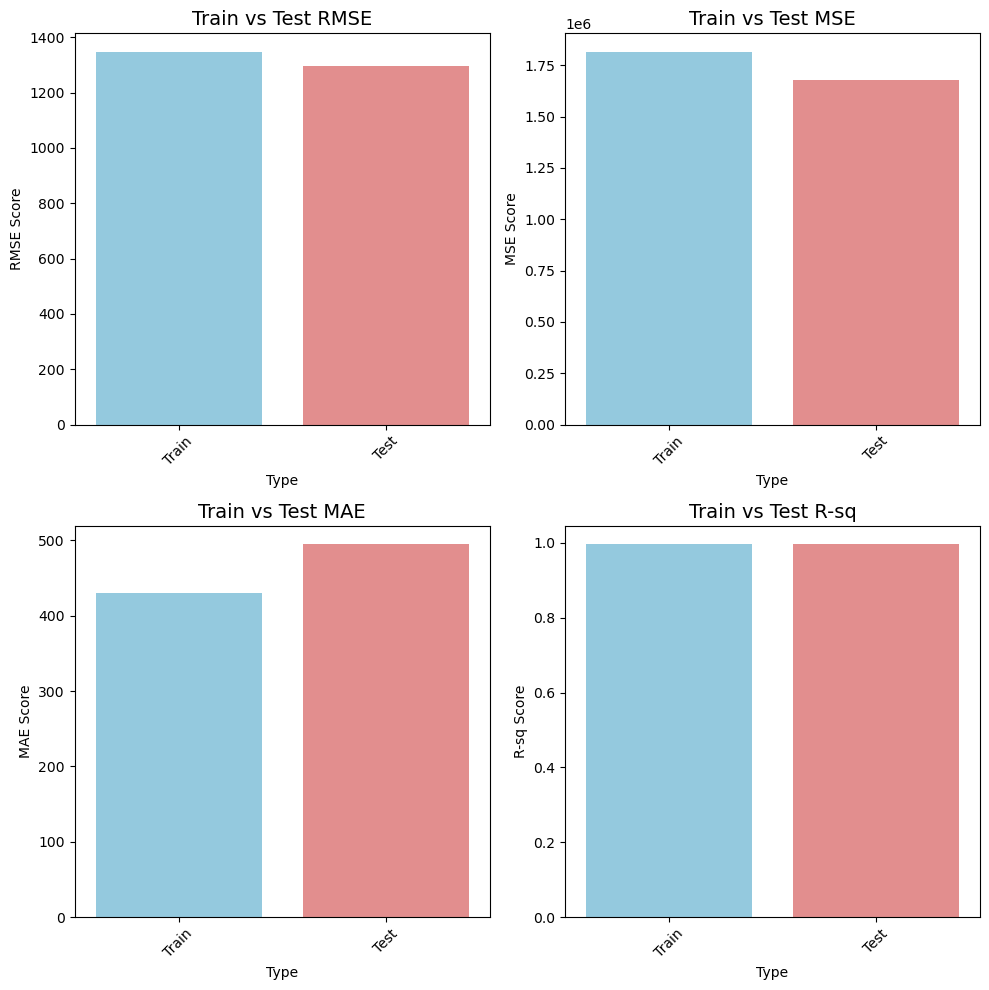

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

SCORE_NAMES = ['RMSE', 'MSE', 'MAE', 'R-sq']

# Random Forest Regression
rfr = RandomForestRegressor(n_estimators=20, min_samples_leaf=10, min_samples_split=10)

# Train Model
rfr.fit(X_train_full, y_train_full)

# Predictions on training and testing sets
y_pred_train = rfr.predict(X_train_full)
y_pred_test = rfr.predict(X_test_full)

# Calculate training and testing performance
rfr_train_scores = perf_cal(y_train_full, y_pred_train)
rfr_test_scores = perf_cal(y_test_full, y_pred_test)

# Extract scores for plotting
train_scores = [rfr_train_scores.loc['Performance Metrics', name] for name in SCORE_NAMES]
test_scores = [rfr_test_scores.loc['Performance Metrics', name] for name in SCORE_NAMES]
score_names = SCORE_NAMES

# Create DataFrame for seaborn
df_plot = pd.DataFrame({
    'Metric': score_names * 2,  # Repeat score names for train and test
    'Score': train_scores + test_scores,  # Combine train and test scores
    'Type': ['Train'] * len(train_scores) + ['Test'] * len(test_scores)  # Label for train and test
})

# Set up the figure for subplots
plt.figure(figsize=(10, 10))

# Iterate through the score names and plot each as a separate subplot
for index, name in enumerate(SCORE_NAMES):
    plt.subplot(2, 2, index + 1)
    
    # Filter data for the current metric
    data_to_plot = df_plot[df_plot['Metric'] == name]
    
    # Use seaborn's barplot with hue
    sns.barplot(x='Type', y='Score', hue='Type', data=data_to_plot, palette={'Train': 'skyblue', 'Test': 'lightcoral'}, dodge=False, legend=False)
    
    # Title and aesthetic adjustments
    plt.title(f"Train vs Test {name}", fontsize=14)
    plt.ylabel(f"{name} Score")
    plt.xticks(rotation=45)

# Adjust layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()


**Linear Regression**

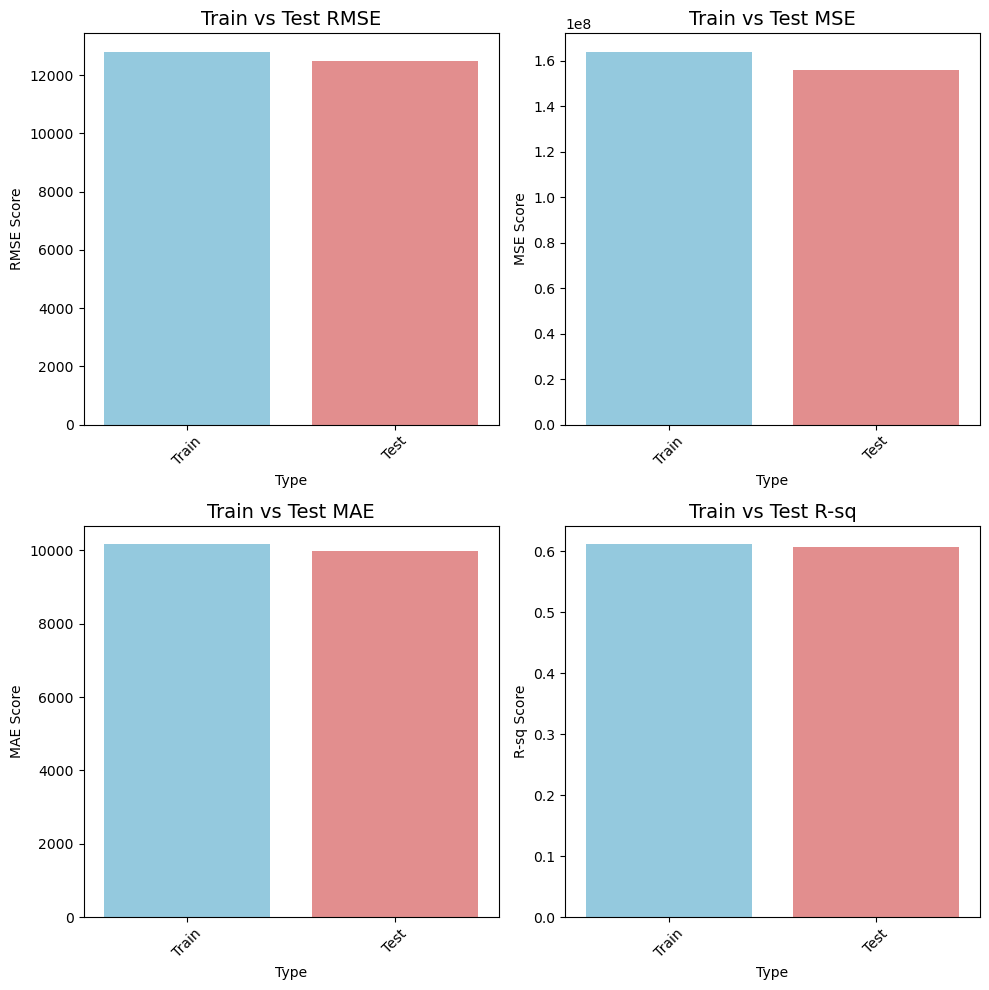

In [236]:
# Linear Regression

# Linear Regression
lr = LinearRegression()

# Train Model
lr.fit(X_train_full, y_train_full)

# Predictions on training and testing sets
y_pred_train = lr.predict(X_train_full)
y_pred_test = lr.predict(X_test_full)

# Calculate training and testing performance
lr_train_scores = perf_cal(y_train_full, y_pred_train)
lr_test_scores = perf_cal(y_test_full, y_pred_test)

# Extract scores for plotting
train_scores = [lr_train_scores.loc['Performance Metrics', name] for name in SCORE_NAMES]
test_scores = [lr_test_scores.loc['Performance Metrics', name] for name in SCORE_NAMES]

# Create DataFrame for seaborn
df_plot = pd.DataFrame({
    'Metric': SCORE_NAMES * 2,  # Repeat score names for train and test
    'Score': train_scores + test_scores,  # Combine train and test scores
    'Type': ['Train'] * len(train_scores) + ['Test'] * len(test_scores)  # Label for train and test
})

# Set up the figure for subplots
plt.figure(figsize=(10, 10))

# Iterate through the score names and plot each as a separate subplot
for index, name in enumerate(SCORE_NAMES):
    plt.subplot(2, 2, index + 1)
    
    # Filter data for the current metric
    data_to_plot = df_plot[df_plot['Metric'] == name]
    
    # Use seaborn's barplot with hue, and set legend=False to avoid multiple legends
    sns.barplot(x='Type', y='Score', hue='Type', data=data_to_plot, palette={'Train': 'skyblue', 'Test': 'lightcoral'}, dodge=False, legend=False)
    
    # Title and aesthetic adjustments
    plt.title(f"Train vs Test {name}", fontsize=14)
    plt.ylabel(f"{name} Score")
    plt.xticks(rotation=45)

# Adjust layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()



After modelling with Decision Tree Regression, I found that it displayed some decent performance. However, I tried Random Forest Regression for better performance, which resulted in a slight improvement in the model's performance. Linear Model has not shown any improvement.

#### Model evaluation and summary of results 


In [240]:
import time

# List of models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=20, min_samples_leaf=10, min_samples_split=10),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=10),
    'Linear Regression': LinearRegression()
}

# Initialize a dictionary to store results
results = {}
execution_times = {}  # To store execution times

# Iterate over each model
for model_name, model in models.items():
    # Measure the start time
    start_time = time.time()
    
    # Train model
    model.fit(X_train_full, y_train_full)

    # Measure the end time and calculate execution time
    execution_time = time.time() - start_time
    execution_times[model_name] = execution_time
    
    # Predictions on train and test sets
    y_pred_train = model.predict(X_train_full)
    y_pred_test = model.predict(X_test_full)
    
    # Calculate performance on train and test sets
    train_scores = perf_cal(y_train_full, y_pred_train)
    test_scores = perf_cal(y_test_full, y_pred_test)
    
    # Store the results in a DataFrame
    results[model_name] = pd.concat([train_scores, test_scores], keys=['Train', 'Test'])

# Create a final DataFrame to compare all models
comparison_df = pd.concat(results, axis=1)
comparison_df.columns = comparison_df.columns.swaplevel(0, 1)
comparison_df = comparison_df.sort_index(axis=1)

# Display the final comparison matrix
print(comparison_df)

# Print the execution times for each model
print("\nModel Execution Times (in seconds):")
for model_name, exec_time in execution_times.items():
    print(f"{model_name}: {exec_time:.4f} seconds")


                                    MAE                                  \
                          Decision Tree Linear Regression Random Forest   
Train Performance Metrics   1290.321561      10164.570292    396.964625   
Test  Performance Metrics   1479.655080       9992.174054    476.504413   

                                    MSE                                  \
                          Decision Tree Linear Regression Random Forest   
Train Performance Metrics  8.551431e+06      1.638717e+08  1.598852e+06   
Test  Performance Metrics  1.060347e+07      1.561563e+08  1.608977e+06   

                                   R-sq                                  \
                          Decision Tree Linear Regression Random Forest   
Train Performance Metrics      0.979729          0.611542      0.996210   
Test  Performance Metrics      0.973391          0.608132      0.995962   

                                   RMSE                                  
                       

**Based on above evaluation, Random Forest is more accurate than other two model but take more time to train.Hence Random forest is best choice so far.** 

## Cross-validation of models

**Cross validation for Decision Tree Regressor**

In [245]:

from sklearn.model_selection import GridSearchCV, cross_val_score

# Define the grid of hyperparameters to search for Decision Tree
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples to split a node
    'min_samples_leaf': [1, 2, 4]  # Minimum number of samples at a leaf node
}

# Set up GridSearchCV for Decision Tree with 5-fold cross-validation
grid_search_dt = GridSearchCV(estimator=dtr, param_grid=param_grid_dt, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Train the DecisionTreeRegressor using grid search
grid_search_dt.fit(X_train, y_train)

# Get the best parameters from grid search for Decision Tree
best_params_dt = grid_search_dt.best_params_
print("Best parameters for Decision Tree: ", best_params_dt)

# Train the best model found using cross-validation
best_dt = grid_search_dt.best_estimator_

# Cross-validation scores (MSE)
cv_scores_dt = cross_val_score(best_dt, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Display Cross-validation scores
print("Cross-validation MSE scores (Decision Tree): ", -cv_scores_dt)
print("Average CV MSE (Decision Tree): ", -cv_scores_dt.mean())

# Test Set Evaluation
y_pred_dt = best_dt.predict(X_test)
test_mse_dt = mean_squared_error(y_test, y_pred_dt)
test_rmse_dt = np.sqrt(test_mse_dt)
test_r2_dt = r2_score(y_test, y_pred_dt)

print(f"Test RMSE (Decision Tree): {test_rmse_dt}")
print(f"Test R^2 (Decision Tree): {test_r2_dt}")


Best parameters for Decision Tree:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Cross-validation MSE scores (Decision Tree):  [82729305.05081585 83906628.15887235 84147887.03339791 87483197.77799377
 79103621.15860912]
Average CV MSE (Decision Tree):  83474127.83593781
Test RMSE (Decision Tree): 8955.265883655347
Test R^2 (Decision Tree): 0.7987495863230817


**Cross validation for Random Regressor**

In [248]:
# Cross-validation for Random Forest Regression
cv_scores_rfr = cross_val_score(rfr, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Display Cross-validation scores
print("Cross-validation MSE scores (Random Forest Regression): ", -cv_scores_rfr)
print("Average CV MSE (Random Forest Regression): ", -cv_scores_rfr.mean())

# Train the model and test on test set
rfr.fit(X_train, y_train)
y_pred_rfr = rfr.predict(X_test)

# Test Set Evaluation
test_mse_rfr = mean_squared_error(y_test, y_pred_rfr)
test_rmse_rfr = np.sqrt(test_mse_rfr)
test_r2_rfr = r2_score(y_test, y_pred_rfr)

print(f"Test RMSE (Random Forest Regression): {test_rmse_rfr}")
print(f"Test R^2 (Random Forest Regression): {test_r2_rfr}")

Cross-validation MSE scores (Random Forest Regression):  [83525568.11721037 84354194.46525356 86285441.06660065 87910199.5741437
 79459641.51007015]
Average CV MSE (Random Forest Regression):  84307008.94665568
Test RMSE (Random Forest Regression): 8974.851851229245
Test R^2 (Random Forest Regression): 0.7978683183550251


**Selecting the best model**

After taking into account the accuracy, and overall performance Random forest is the choice. However other Model also need to try like SARMA for seasonality and  LSTMs (Long Short-Term Memory networks) for improved time series forecasting.